# Tutorial 6: Genome-browser plotting with a trained model

Tutorial 2 introduced the composable `track_plot` API for drawing genome-browser-style figures from a G-Tensor. Tutorial 4 touched on two model-aware composites (`plot_marginal_observed_vs_expected` and `plot_component_rates`). This tutorial is a comprehensive tour of everything that becomes available **once you have a trained topographic model annotating your G-Tensor** — per-component rates, the topography heatmap, strand-aware gene-expression tracks, gene annotations, and a full hypothesis-generation dashboard you can point at any region of the genome.

We won't re-teach the primitives from Tutorial 2 (`scatterplot`, `line_plot`, `fill_plot`, `stack_plots`, `pipeline`, `select`, `make_view`, `plot_view`) — glance back at that tutorial if anything feels unfamiliar.

## Prerequisites

- MuTopia package installed
- The shared tutorial data bundle from the [Zenodo record](https://zenodo.org/records/18803136) unpacked to `tutorial_data/` — see [Tutorial data](index.html#tutorial-data)
- A trained model at `tutorial_data/pretrained_model.pkl` (shipped in the bundle; also produced by Tutorial 3)
- A cytoband file at `tutorial_data/cytoBand.txt` and the MANE GTF at `tutorial_data/MANE.GRCh38.v1.3.ensembl_genomic.gtf` (both shipped in the bundle)

## What we'll build

1. **Observed vs predicted** — peel a composite track apart into primitives and back
2. **Per-component rates** — ordered, labeled, hierarchically clustered
3. **The topography heatmap** — `TopographyTransformer` + `plot_topography` + empirical overlay
4. **Feature context** — heatmaps of chromatin features, strand-aware expression, gene annotations
5. **A reusable dashboard** — one config, three regions, zero copy-paste

## Setup

Load the model, annotate the dataset, and rename components up front. Renaming is optional but makes every subsequent plot (and every legend) readable — once we've labeled components `SBS1`, `SBS5`, etc., everything downstream inherits those names.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import mutopia.analysis as mu
import mutopia.plot.track_plot as tr

model = mu.load_model('tutorial_data/pretrained_model.pkl')
data  = mu.gt.load_dataset('tutorial_data/Liver.nc', with_samples=False)
data  = model.annot_data(data, threads=4, calc_shap=False)

components = mu.gt.list_components(data)

/Users/allen/miniconda3/envs/mutopia-model/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO     Mutopia JIT-compiling model operations ...
INFO     Mutopia Setting up dataset state ...
INFO     Mutopia Done ...
INFO     Mutopia Setting model to prediction mode.
Estimating contributions: 100%|██████████████████████████████████| 185/185 [00:01<00:00, 152.36it/s]
INFO     Mutopia Added key to dataset: "contributions"
INFO     Mutopia Added keys to dataset: Spectra/spectra, Spectra/interactions, Spectra/shared_effects
INFO     Mutopia Added key: "component_distributions"
INFO     Mutopia Added key: "component_distributions_locus"
INFO     Mutopia Added key: "predicted_marginal"
INFO     Mutopia Added key: "predicted_marginal_locus"
Reducing samples: 100%|██████████| 184/184 [00:27<00:00,  6.76it/s]
INFO

Inspect the learned spectra (Tutorial 4 covers this in depth) and assign biologically meaningful names in the same order. For a 15-component liver model, the dominant signatures typically line up with SBS1 (clock-like CpG deamination), SBS5 (clock-like), SBS16 (liver-specific), SBS22 (aristolochic acid), SBS40, and a handful of low-activity processes. Use `mu.pl.plot_signature_panel(data)` to decide the mapping for your own model.

> **Tip:** If you're not ready to commit to a mapping yet, skip this cell — every plot below also works with the raw `M0..M14` labels.

In [2]:
# Replace with the mapping that makes sense for your model.
# Check against mu.pl.plot_signature_panel(data) first!
new_names = [
    'SBS1', 'SBS5', 'SBS16', 'SBS22', 'SBS40',
    'SBS12', 'SBS18', 'SBS4',  'SBS17b','SBS6',
    'M10',   'M11',  'M12',    'M13',   'M14',
]
data = mu.gt.rename_components(data, new_names)
components = mu.gt.list_components(data)

Make a single `GenomeView` we can pass into every configuration in this tutorial. We're picking a gene-rich 5 Mb window on chr2; Step 5 will swap in other views without touching the config.

In [3]:
view = tr.make_view(data, 'chr2:55_000_000-85_000_000', title='chr2 gene-rich window')

INFO     Mutopia Found 4338/388247 regions matching query.


## 1. Observed vs predicted: primitives → composite

`plot_marginal_observed_vs_expected` is the single most useful model-aware track: it overlays the empirical mutation rate (from your samples) on the model's locus-level prediction. Before we use the composite, let's build it by hand out of primitives so the machinery is transparent.

The two variables we need are both added to `data` by `model.annot_data`:

- `empirical_marginal_locus` — observed mutations per locus, summed over context and configuration
- `predicted_marginal_locus` — model-predicted rate per locus

`view.smooth(n)` is a pipeline step that convolves along the genomic axis of any selected variable.

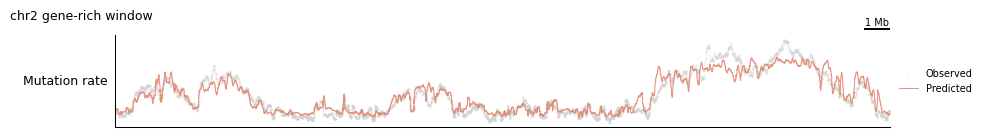

In [4]:
manual_config = lambda view, scalebar_bp: (
    tr.scale_bar(scalebar_bp, scale='mb'),
    tr.stack_plots(
        tr.scatterplot(
            tr.pipeline(
                tr.select('empirical_marginal_locus'),
                view.smooth(20),
                tr.renorm,
            ),
            s=0.1, alpha=0.5, color='lightgrey', label='Observed',
        ),
        tr.line_plot(
            tr.pipeline(
                tr.select('predicted_marginal_locus'),
                view.smooth(10),
                tr.renorm,
            ),
            color=mu.pl.categorical_palette[1],
            linewidth=0.75, alpha=0.8, label='Predicted',
        ),
        label='Mutation rate',
        legend=True,
        height=1.25,
    ),
)

tr.plot_view(manual_config, view, scalebar_bp=1_000_000, width=10)
None

That's five lines per track — workable, but it gets repetitive across many regions. The composite does exactly this, with sane defaults:

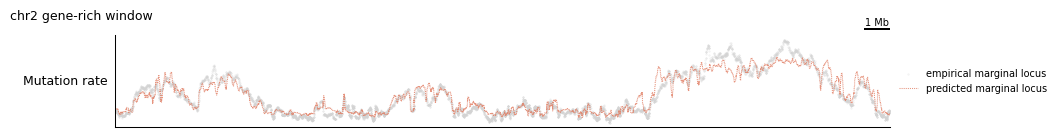

In [5]:
composite_config = lambda view, scalebar_bp: (
    tr.scale_bar(scalebar_bp, scale='mb'),
    tr.tracks.plot_marginal_observed_vs_expected(view, smooth=20, pred_smooth=10, height=1.25),
)

tr.plot_view(composite_config, view, scalebar_bp=1_000_000, width=10)
None

## 2. Per-component mutation rates

Once the model has decomposed the mutation rate into *k* components, each component has its own locus-wise density: `component_distributions_locus[component=<name>]`. `plot_component_rates` returns one `fill_plot` per component, which you can splat into the config tuple.

The real value comes from `order_components`, which performs hierarchical clustering so visually similar components sit next to each other.

Ordered components: ['SBS40' 'SBS18' 'SBS16' 'SBS12' 'M10' 'SBS4' 'M11' 'SBS5' 'M14' 'SBS6'
 'SBS1' 'M12' 'M13' 'SBS17b' 'SBS22']


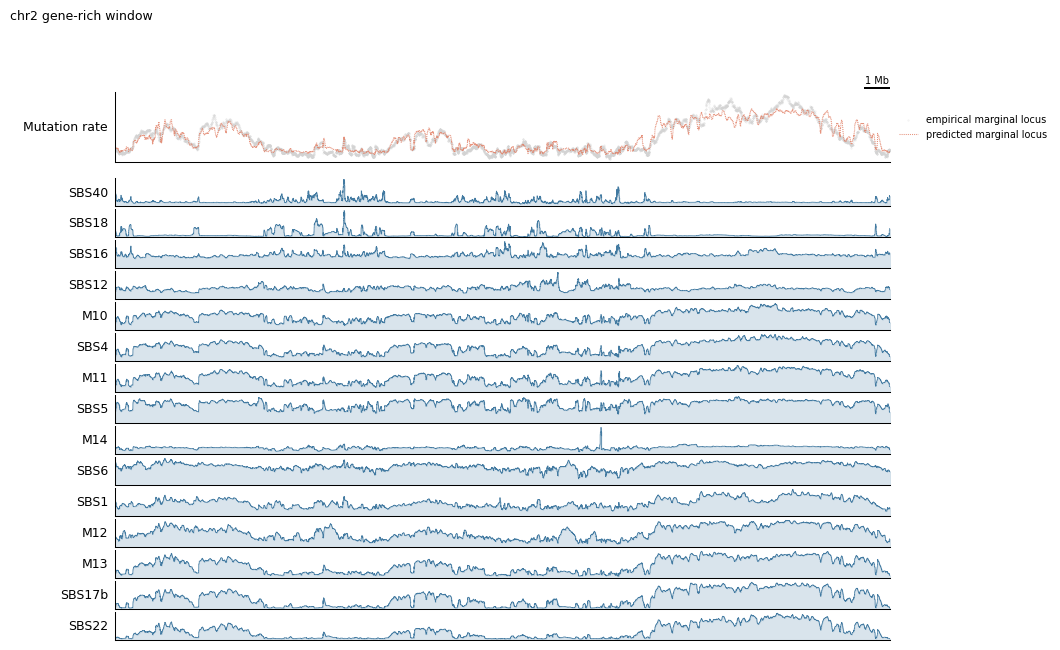

In [6]:
ordered = tr.order_components(data)
print('Ordered components:', ordered)

rates_config = lambda view, scalebar_bp: (
    tr.scale_bar(scalebar_bp, scale='mb'),
    tr.tracks.plot_marginal_observed_vs_expected(view, height=1),
    tr.spacer(0.15),
    *tr.tracks.plot_component_rates(view, *ordered, smooth=10, height=0.4),
)

tr.plot_view(rates_config, view, scalebar_bp=1_000_000, width=10)
None

If you only care about one component — say you want to zoom in on SBS1 — you can grab it directly via `select`'s keyword selection. Any keyword passed to `select` is forwarded to `xarray.DataArray.sel`, so you can pick along *any* named dimension:

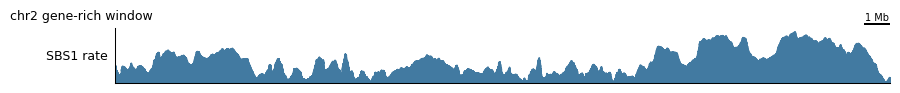

In [7]:
single_config = lambda view, scalebar_bp: (
    tr.scale_bar(scalebar_bp, scale='mb'),
    tr.fill_plot(
        tr.pipeline(
            tr.select('component_distributions_locus', component='SBS1'),
            view.smooth(30),
            tr.renorm,
        ),
        label='SBS1 rate',
        color=mu.pl.categorical_palette[0],
        height=0.75,
    ),
)

tr.plot_view(single_config, view, scalebar_bp=1_000_000, width=10)
None

## 3. The topography heatmap

The **topography** is MuTopia's marquee view: a heatmap whose rows are (mutation type × trinucleotide context × orientation) and whose columns are genomic loci. Each cell is the log-ratio of the predicted per-context mutation rate at that locus to the locus's overall predicted rate. Rows are hierarchically ordered so patterns associated with the same underlying process land together.

`TopographyTransformer` is a lightweight, scikit-learn-style transformer: `.fit(data)` computes the row ordering and per-row mean/std once over the whole dataset, and `.transform(view)` standardizes a slice on demand. `plot_topography` is the heatmap wrapper.

**Fit once, reuse everywhere** — never refit inside a config.

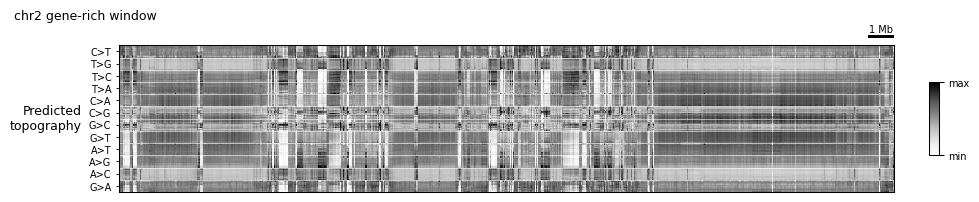

In [8]:
topography = tr.TopographyTransformer(data_key='predicted_marginal').fit(data)

topo_config = lambda view, scalebar_bp: (
    tr.scale_bar(scalebar_bp, scale='mb'),
    tr.tracks.plot_topography(topography, height=2.0),
)

tr.plot_view(topo_config, view, scalebar_bp=1_000_000, width=10)
None

## 4. Feature context

The model tracks above tell you *what* is happening with mutagenesis. To understand *why*, you usually want to layer in the underlying genomic features (chromatin, expression, genes).

### 4a. Chromatin feature heatmap

`feature_matrix` stacks any number of features into a (feature, locus) matrix, which `heatmap_plot` can render with optional hierarchical row clustering. `clip` trims outliers before plotting.

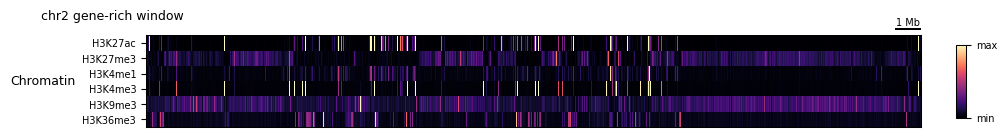

In [9]:
chromatin_features = ['H3K27ac', 'H3K27me3', 'H3K4me1', 'H3K4me3', 'H3K9me3', 'H3K36me3']

chromatin_config = lambda view, scalebar_bp: (
    tr.scale_bar(scalebar_bp, scale='mb'),
    tr.heatmap_plot(
        tr.pipeline(
            tr.feature_matrix(*chromatin_features),
            tr.clip(0.02, 0.98),
            tr.apply_rows(tr.minmax_scale),
        ),
        palette='magma',
        row_cluster=False,
        label='Chromatin',
        yticks=True,
        height=1.25,
    ),
)

tr.plot_view(chromatin_config, view, scalebar_bp=1_000_000, width=10)
None

### 4b. Strand-aware gene expression

`plot_gene_expression_track` is a composite that combines the `GeneExpression` magnitude feature with the `GeneStrand` feature (+1 / −1 / 0), producing a signed bar plot. With `log1p=True` it applies a symmetric log transform so both strongly-expressed strands are visible at once.

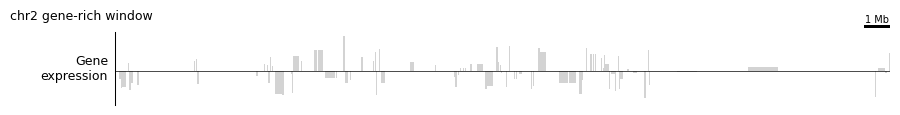

In [10]:
expression_config = lambda view, scalebar_bp: (
    tr.scale_bar(scalebar_bp, scale='mb'),
    tr.tracks.plot_gene_expression_track(
        expression_key='GeneExpression',
        strand_key='GeneStrand',
        log1p=True,
        height=1.0,
    ),
)

tr.plot_view(expression_config, view, scalebar_bp=1_000_000, width=10)
None

### 4c. Gene annotation

`plot_gene_annotation` drops in a real GTF-backed gene track (built on top of `pygenometracks`), which is the quickest way to make a figure biologically interpretable.

INFO     Mutopia Loading track data from MANE.GRCh38.v1.3.ensembl_genomic.gtf ...
100%|██████████| 19352/19352 [00:05<00:00, 3382.24it/s]
DEBUG:pygenometracks.tracks.GenomeTrack:ylim 44.779999999999994,-0.08
DEBUG:pygenometracks.tracks.GenomeTrack:ylim (np.float64(44.779999999999994), np.float64(-0.08))


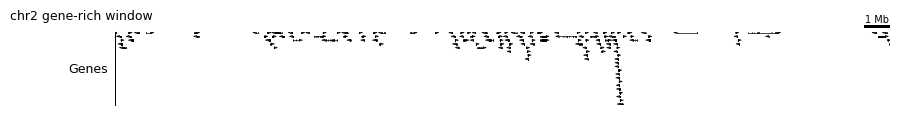

In [11]:
genes_config = lambda view, scalebar_bp: (
    tr.scale_bar(scalebar_bp, scale='mb'),
    tr.tracks.plot_gene_annotation(
        gtf='MANE.GRCh38.v1.3.ensembl_genomic.gtf',
        label='Genes',
        height=1.0,
    ),
)

tr.plot_view(genes_config, view, scalebar_bp=1_000_000, width=10)
None

## 5. The full dashboard

Everything above has been a single-purpose figure. The payoff of the configuration-as-function pattern is that you can glue all of these tracks into one dashboard, then point it at any region of the genome with zero changes.

The dashboard below stacks, top to bottom:

1. Scale bar + ideogram (orientation)
2. Observed vs predicted mutation rate (model fit quality)
3. Per-component rates (which signature is active where)
4. Predicted topography heatmap (per-context fine structure)
5. Chromatin heatmap (epigenomic state)
6. Strand-aware gene expression
7. Gene annotation

DEBUG:pygenometracks.tracks.GenomeTrack:ylim 44.779999999999994,-0.08
DEBUG:pygenometracks.tracks.GenomeTrack:ylim (np.float64(44.779999999999994), np.float64(-0.08))


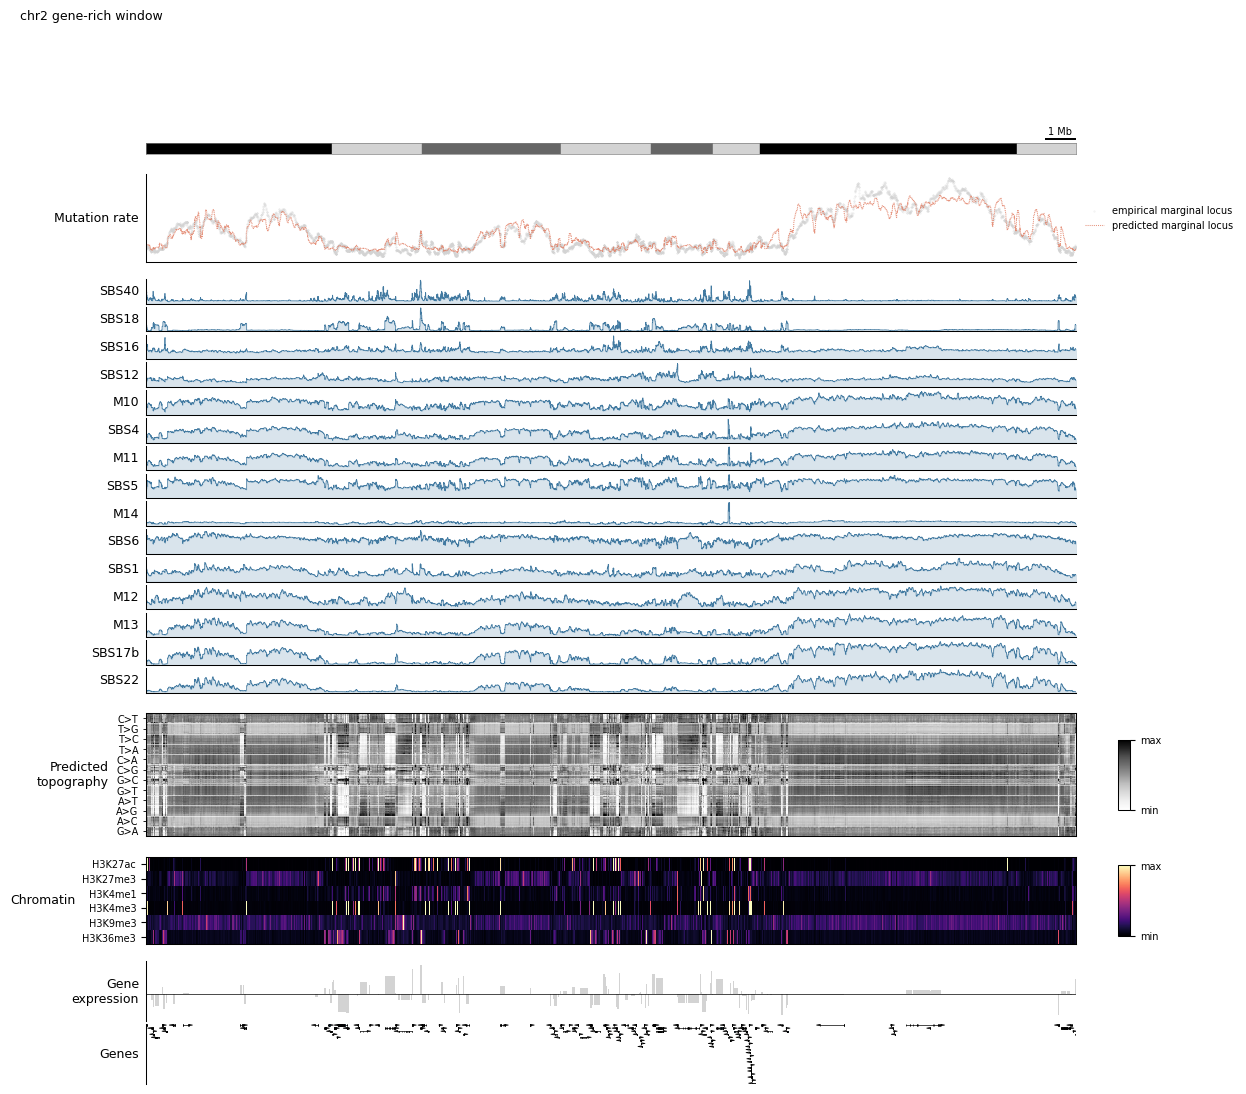

In [12]:
dashboard = lambda view, scalebar_bp: (
    tr.scale_bar(scalebar_bp, scale='mb'),
    tr.ideogram('tutorial_data/cytoBand.txt'),
    tr.spacer(0.2),
    tr.tracks.plot_marginal_observed_vs_expected(view, height=1.25),
    tr.spacer(0.15),
    *tr.tracks.plot_component_rates(view, *ordered, smooth=5, height=0.35),
    tr.spacer(0.2),
    tr.tracks.plot_topography(topography, height=1.75),
    tr.spacer(0.2),
    tr.heatmap_plot(
        tr.pipeline(
            tr.feature_matrix(*chromatin_features),
            tr.clip(0.02, 0.98),
            tr.apply_rows(tr.minmax_scale),
        ),
        palette='magma',
        label='Chromatin',
        yticks=True,
        height=1.25,
    ),
    tr.spacer(0.15),
    tr.tracks.plot_gene_expression_track(height=0.85),
    tr.tracks.plot_gene_annotation(
        gtf='MANE.GRCh38.v1.3.ensembl_genomic.gtf',
        label='Genes',
        height=0.85,
    ),
)

tr.plot_view(dashboard, view, scalebar_bp=1_000_000, width=12)
None

Now the real demonstration: *swap the view, keep the dashboard*. Each of these calls produces a completely different figure from the same `dashboard` function. This is the workflow pattern to steal — build a dashboard once, then fly around the genome.

INFO     Mutopia Found 2235/388247 regions matching query.
DEBUG:pygenometracks.tracks.GenomeTrack:ylim 10.28,-0.08
DEBUG:pygenometracks.tracks.GenomeTrack:ylim (np.float64(10.28), np.float64(-0.08))


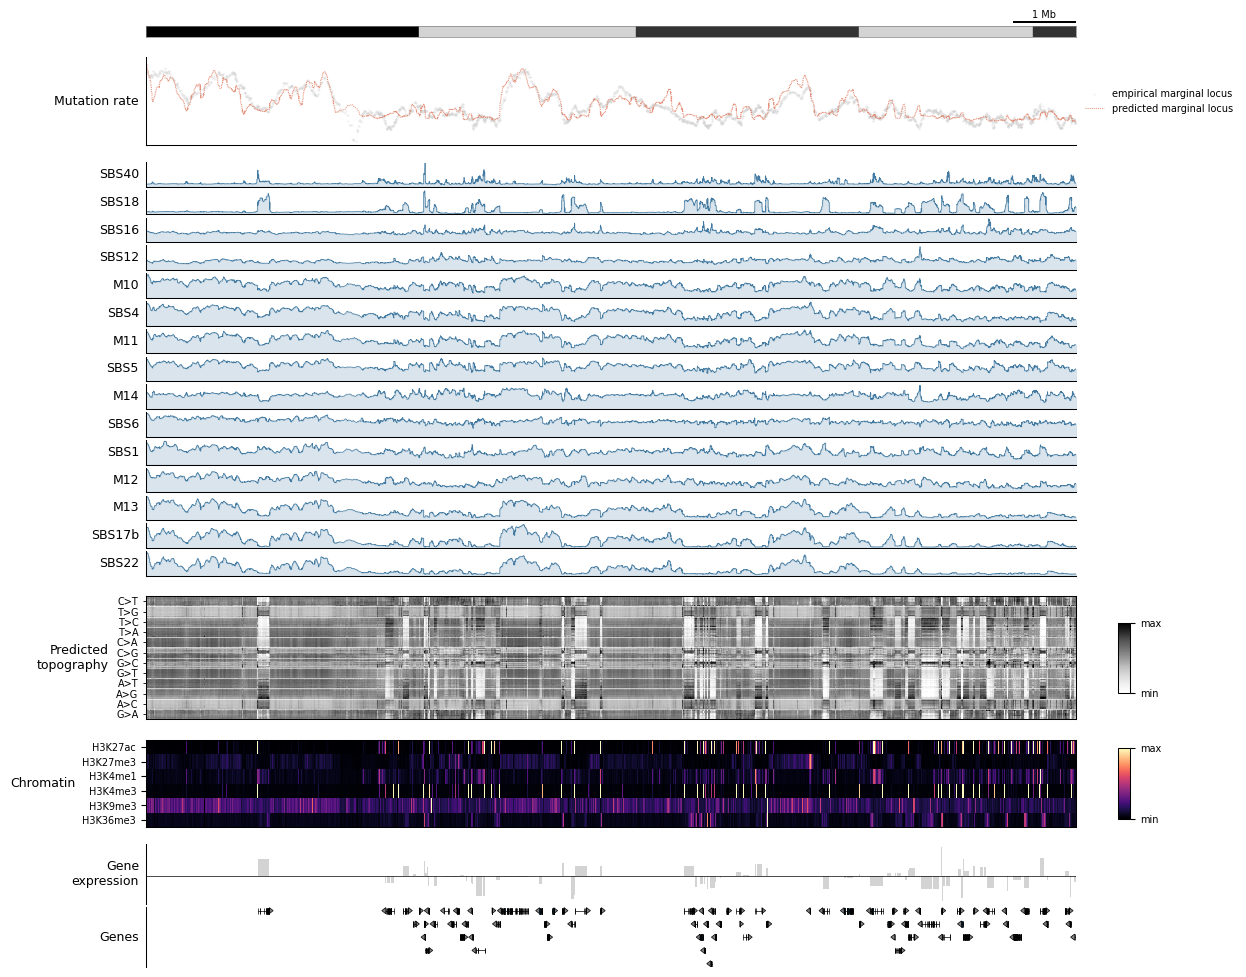

In [13]:
# A heterochromatic desert on chr1 — expect low predicted rate, sparse genes.
view_desert = tr.make_view(data, 'chr1:80_000_000-95_000_000')
tr.plot_view(dashboard, view_desert, scalebar_bp=1_000_000, width=12)
None

## Appendix: escape hatches

The composites above cover the common cases, but you'll eventually want to drop in something the library doesn't provide. Three ways out:

- **`tr.custom_plot(fn, height=...)`** — wrap a raw function `fn(ax, *, dataset, start, end, idx, interval, **kw)` and stick it in a config like any other track. This is how every composite is built internally.
- **`tr.columns(a, b, ..., width_ratios=[...])`** — put tracks side-by-side instead of stacked. Useful for a narrow summary column next to a wide genome track. Pass `...` (the `Ellipsis`) as a placeholder to leave a column blank.
- **`tr.static_track(track_type='bigwig', file='path/to/file.bw', height=0.5, **props)`** — wraps an arbitrary `pygenometracks` track. Drops any BigWig/BED/GTF from disk straight into your figure without going through the G-Tensor at all.

Here's a minimal `custom_plot` example that shades the top 5% mutated loci in the current view. Notice that MuTopia passes the full `dataset`, the `start`/`end` coordinates of each locus in the view, and the integer `idx` selector — that's the contract every track obeys.

## Next steps

- **Tutorial 4** — signature spectra, SHAP feature importance, component interaction matrices. Everything here is a per-region view; Tutorial 4 covers the global view.
- **Tutorial 5** — apply the same trained model to annotate your own VCFs with per-mutation component posteriors.
- Dig into `mutopia/plot/track_plot/tracks.py` — every composite in this tutorial is ~20 lines and a good template for building your own.